In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neuralforecast.core import NeuralForecast
from neuralforecast.models import NHITS, NBEATS, TimesNet
from neuralforecast.losses.numpy import mae, mse
from pathlib import Path

In [3]:
df = pd.read_csv(r'data/longest_patient_measurements.csv')
df['unique_id'] = 'OT'
df['y'] = df['SI']

# maxlen = 0
# for i, row in enumerate(df.iterrows()):
#     if len(row[1]) > maxlen:
#         maxlen = len(row[1])

# print(maxlen)

df['ds'] = pd.to_datetime(df['ds'])

print(df.head())

   Unnamed: 0        SI                  ds unique_id         y
0           0  0.000412 2023-01-01 00:00:00        OT  0.000412
1           1  0.000230 2023-01-01 01:00:00        OT  0.000230
2           2  0.000165 2023-01-01 02:00:00        OT  0.000165
3           3  0.000178 2023-01-01 03:00:00        OT  0.000178
4           4  0.000170 2023-01-01 04:00:00        OT  0.000170


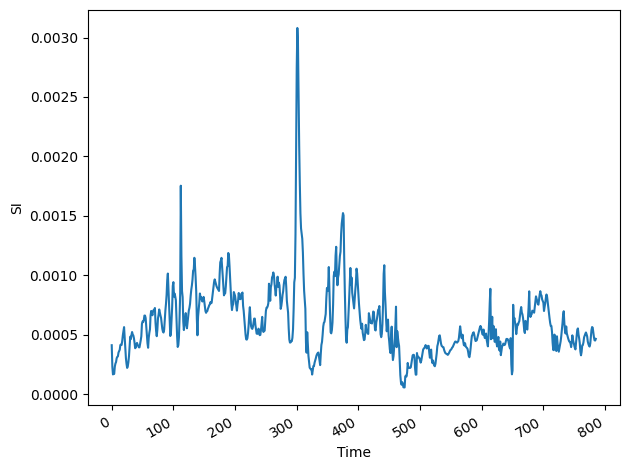

In [4]:
fig, ax = plt.subplots()

ax.plot(df['SI'])
ax.set_xlabel('Time')
ax.set_ylabel('SI')

fig.autofmt_xdate()
plt.tight_layout()
# plt.savefig("img_0.png")
plt.show()

In [8]:
horizon = 96

models = [NHITS(h=horizon,
               input_size=2*horizon,
               max_steps=50),
         NBEATS(h=horizon,
               input_size=2*horizon,
               max_steps=50),
         TimesNet(h=horizon,
                 input_size=2*horizon,
                 max_steps=50)]


nf = NeuralForecast(models=models, freq='H')
preds_df = nf.cross_validation(df=df, step_size=horizon, n_windows=2)


Seed set to 1
Seed set to 1
Seed set to 1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

0


,unique_id,ds,cutoff,NHITS,NBEATS,TimesNet,Unnamed: 0,SI,y
187,OT,2023-02-02 13:00:00,2023-01-29 17:00:00,0.001114,-0.000652,0.000349,781,0.000518,0.000518
188,OT,2023-02-02 14:00:00,2023-01-29 17:00:00,0.000975,0.002448,0.000445,782,0.000478,0.000478
189,OT,2023-02-02 15:00:00,2023-01-29 17:00:00,0.001367,-0.000293,0.000415,783,0.000453,0.000453
190,OT,2023-02-02 16:00:00,2023-01-29 17:00:00,0.000528,0.001508,0.000424,784,0.000451,0.000451
191,OT,2023-02-02 17:00:00,2023-01-29 17:00:00,0.000527,0.010209,0.000480,785,0.000465,0.000465


In [ ]:
print(len(preds_df) - 2 * horizon)

preds_df.tail()

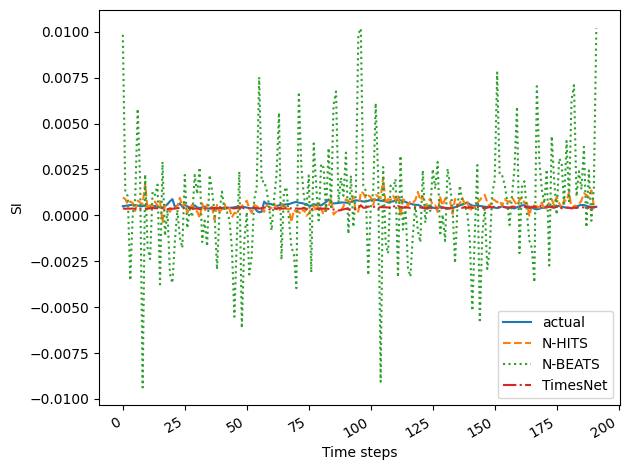

In [6]:
fig, ax = plt.subplots()

ax.plot(preds_df['SI'], label='actual')
ax.plot(preds_df['NHITS'], label='N-HITS', ls='--')
ax.plot(preds_df['NBEATS'], label='N-BEATS', ls=':')
ax.plot(preds_df['TimesNet'], label='TimesNet', ls='-.')

ax.legend(loc='best')
ax.set_xlabel('Time steps')
ax.set_ylabel('SI')

fig.autofmt_xdate()
# plt.ylim(-0.001, 0.001)
plt.tight_layout()
plt.savefig('out.png')

In [7]:
data = {'N-HiTS': [mae(preds_df['NHITS'], preds_df['y']), mse(preds_df['NHITS'], preds_df['y'])],
       'N-BEATS': [mae(preds_df['NBEATS'], preds_df['y']), mse(preds_df['NBEATS'], preds_df['y'])],
       'TimesNet': [mae(preds_df['TimesNet'], preds_df['y']), mse(preds_df['TimesNet'], preds_df['y'])]}

metrics_df = pd.DataFrame(data=data)
metrics_df.index = ['mae', 'mse']

metrics_df.style.highlight_min(color='lightgreen', axis=1)
metrics_df

,N-HiTS,N-BEATS,TimesNet
mae,2.840637e-04,0.002170,1.539384e-04
mse,1.308946e-07,0.000009,4.081940e-08
